# Scalability Report

Interactive view of the pairwise scalability benchmark. Reads the per-pair CSV written by `scripts/scalability_run.py`.
This notebook is intended for anyone who wants to inspect the run beyond the headline numbers cited in the paper's maturity section.

**Per-pair pipeline.** Each row is one unordered pair (model_a, model_b) of internal BPMN models. The pipeline ran three stages, each timed independently. For the specific run, we selected Dice as set-metric.

- `t_semantic` — sentence-transformer name alignment
- `t_structural` — set-based BPMN-element similarity
- `t_behavioral` — Petri-net trace extraction on both sides (timeout 30 s per side, `max_loop_depth=2`)

`t_total` is the wall-clock for the whole pipeline on that pair, including everything outside the three stages (model lookup, CSV write).

## 1. Load the benchmark CSV

Default path is `results/scalability_run.csv`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CSV_PATH = REPO_ROOT / 'results' / 'scalability_run.csv'

df = pd.read_csv(CSV_PATH)
print(f'CSV:    {CSV_PATH}')
print(f'columns: {list(df.columns)}')
df.head()

CSV:    /Users/I762870/dev/process-evaluation-framework/results/scalability_run.csv
columns: ['pair_id', 'model_a', 'model_b', 'size_a', 'size_b', 't_semantic', 't_structural', 't_behavioral', 't_total', 'behavioral_timed_out_a', 'behavioral_timed_out_b', 'structural_overall', 'behavioral_score', 'error']


,pair_id,model_a,model_b,size_a,size_b,t_semantic,t_structural,t_behavioral,t_total,behavioral_timed_out_a,behavioral_timed_out_b,structural_overall,behavioral_score,error
0,0_1,model_1,model_2,4,16,0.764658,0.000188,0.004463,0.769311,False,False,0.075000,0.0,NaN
1,0_2,model_1,model_3,4,12,0.441162,0.000106,0.001849,0.443119,False,False,0.080000,0.0,NaN
2,0_3,model_1,model_4,4,13,0.270731,0.000108,0.010176,0.281017,False,False,0.067273,0.0,NaN
3,0_4,model_1,model_5,4,10,0.297468,0.000106,0.001285,0.298861,False,False,0.100000,0.0,NaN
4,0_5,model_1,model_6,4,11,0.281045,0.000112,0.005838,0.286997,False,False,0.062500,0.0,NaN


## 2. Run health

Counts of failed pairs and pairs that hit the Petri-net timeout on at least one side. Failed pairs (non-empty `error` column) are dropped from the numeric aggregation below; timeout pairs are kept (they did run, just with partial trace coverage).

In [2]:
errored = df[df['error'].notna() & (df['error'] != '')]
ok = df[~df.index.isin(errored.index)].copy()

# CSV stores booleans as the strings 'True' / 'False'. Coerce defensively.
def _as_bool(col):
    return col.astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

ok['behavioral_timed_out_a'] = _as_bool(ok['behavioral_timed_out_a'])
ok['behavioral_timed_out_b'] = _as_bool(ok['behavioral_timed_out_b'])
ok['behavioral_timed_out'] = ok['behavioral_timed_out_a'] | ok['behavioral_timed_out_b']

n_total = len(df)
n_err = len(errored)
n_ok = len(ok)
n_timeout = int(ok['behavioral_timed_out'].sum())

print(f'total pair rows:                 {n_total}')
print(f'  succeeded (no error):          {n_ok}')
print(f'  errored:                       {n_err}')
print(f'  with >=1 behavioral timeout:   {n_timeout}  ({100 * n_timeout / max(1, n_ok):.2f}% of OK pairs)')

if n_err:
    print('\nSample errors:')
    for _, row in errored.head(5).iterrows():
        print(f"  {row['pair_id']:>10}  {str(row['error'])[:200]}")

total pair rows:                 11781
  succeeded (no error):          11781
  errored:                       0
  with >=1 behavioral timeout:   6  (0.05% of OK pairs)


## 3. Corpus shape

Each model appears as either `model_a` or `model_b` in many pair rows; `size_a` / `size_b` record its flow-node count (activities + events + gateways).

distinct models:        154
flow-node count:        min=3, median=13, p95=37, max=52


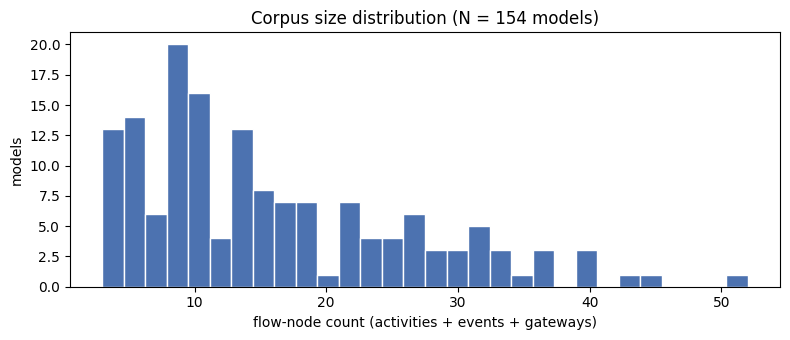

In [3]:
left = ok[['model_a', 'size_a']].rename(columns={'model_a': 'model', 'size_a': 'size'})
right = ok[['model_b', 'size_b']].rename(columns={'model_b': 'model', 'size_b': 'size'})
sizes = (
    pd.concat([left, right])
      .drop_duplicates(subset='model')
      .reset_index(drop=True)
      .sort_values('size')
)

print(f'distinct models:        {len(sizes)}')
print(f'flow-node count:        min={int(sizes["size"].min())}, '
      f'median={int(sizes["size"].median())}, '
      f'p95={int(sizes["size"].quantile(0.95))}, '
      f'max={int(sizes["size"].max())}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(sizes['size'], bins=30, color='#4c72b0', edgecolor='white')
ax.set_xlabel('flow-node count (activities + events + gateways)')
ax.set_ylabel('models')
ax.set_title(f'Corpus size distribution (N = {len(sizes)} models)')
plt.tight_layout(); plt.show()

## 4. Where does the runtime go?

**Behavioral dominates: 94.6 % of total wall-clock (6 651 s of 7 029 s) is spent on Petri-net trace extraction and comparison.** Per-pair, a typical pair is still cheap — the median pair finishes the behavioral stage in ~5 ms — but a small fraction stretch into the tens of seconds.

The two panels below split those two facts: the left panel shows the *aggregate* time budget across the whole benchmark, the right panel shows what *one pair* actually costs at the median, p95, and max.

In [4]:
STAGES = [
    ('t_semantic',   'Semantic (normalize_atomic_names)',          '#dd8452'),
    ('t_structural', 'Structural (calculate_bpmn_similarity)',     '#55a868'),
    ('t_behavioral', 'Behavioral (extract_traces + trace metric)', '#c44e52'),
    ('t_total',      'Total pipeline',                             '#4c72b0'),
]

for col, _, _ in STAGES:
    ok[col] = pd.to_numeric(ok[col], errors='coerce')

stats_rows = []
for col, label, _ in STAGES:
    v = ok[col].dropna()
    stats_rows.append({
        'stage': label,
        'median': v.median(),
        'mean':   v.mean(),
        'p95':    v.quantile(0.95),
        'p99':    v.quantile(0.99),
        'max':    v.max(),
        'sum (s)': v.sum(),
    })
stats_df = pd.DataFrame(stats_rows)
with pd.option_context('display.float_format', '{:.6f}'.format):
    print(stats_df.to_string(index=False))

                                     stage   median     mean      p95       p99       max     sum (s)
         Semantic (normalize_atomic_names) 0.018203 0.031869 0.094957  0.211472  1.259407  375.448350
    Structural (calculate_bpmn_similarity) 0.000139 0.000154 0.000296  0.000380  0.001032    1.815395
Behavioral (extract_traces + trace metric) 0.004842 0.564597 0.135506 23.519470 42.067239 6651.512204
                            Total pipeline 0.026087 0.596621 0.225163 23.581008 42.154203 7028.787597


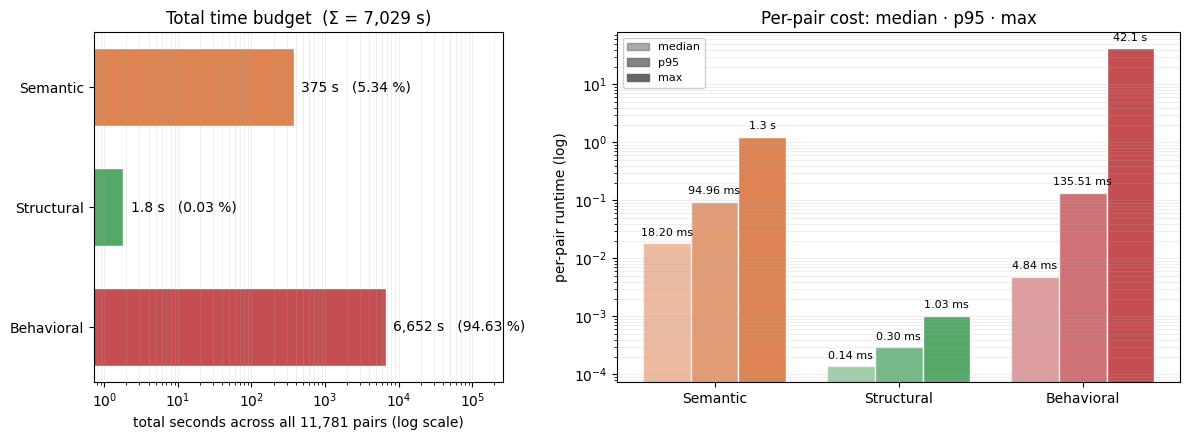

In [5]:
# Two-panel view: (left) total-time budget across all pairs, (right) per-pair percentile costs.
three_stages = [
    ('t_semantic',   'Semantic',   '#dd8452'),
    ('t_structural', 'Structural', '#55a868'),
    ('t_behavioral', 'Behavioral', '#c44e52'),
]
sums = {label: ok[col].sum() for col, label, _ in three_stages}
total = sum(sums.values())

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.5),
                                        gridspec_kw={'width_ratios': [1.6, 2.2]})

# --- Left: one horizontal bar per stage on a log-x axis ---
labels = [label for _, label, _ in three_stages]
colors = [color for _, _, color in three_stages]
values = [sums[l] for l in labels]
y_pos = np.arange(len(labels))
ax_left.barh(y_pos, values, color=colors, edgecolor='white', height=0.65)
for yi, s in zip(y_pos, values):
    pretty = f'{s:,.1f} s' if s < 10 else f'{s:,.0f} s'
    ax_left.text(s * 1.25, yi, f'{pretty}   ({100 * s / total:.2f} %)',
                 va='center', fontsize=10)
ax_left.set_xscale('log')
ax_left.set_xlim(min(values) * 0.4, max(values) * 40)
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(labels)
ax_left.invert_yaxis()
ax_left.set_xlabel('total seconds across all 11,781 pairs (log scale)')
ax_left.set_title(f'Total time budget  (Σ = {total:,.0f} s)')
ax_left.grid(True, which='both', axis='x', alpha=0.2)

# --- Right: per-stage percentile bars (median / p95 / max), log-y with numeric labels ---
percentiles = [('median', 0.50), ('p95', 0.95), ('max', 1.00)]
x = np.arange(len(three_stages))
width = 0.26
for i, (pname, q) in enumerate(percentiles):
    vals = [ok[col].quantile(q) if q < 1 else ok[col].max() for col, _, _ in three_stages]
    ax_right.bar(x + (i - 1) * width, vals, width,
                 color=[c for _, _, c in three_stages],
                 alpha=[0.55, 0.8, 1.0][i],
                 edgecolor='white')
    for xi, v in zip(x + (i - 1) * width, vals):
        label = f'{v*1000:.2f} ms' if v < 1 else f'{v:.1f} s'
        ax_right.text(xi, v * 1.35, label, ha='center', fontsize=8)
ax_right.set_yscale('log')
ax_right.set_xticks(x)
ax_right.set_xticklabels([label for _, label, _ in three_stages])
ax_right.set_ylabel('per-pair runtime (log)')
ax_right.set_title('Per-pair cost: median · p95 · max')
ax_right.grid(True, which='both', axis='y', alpha=0.2)
# Faint legend to disambiguate the alpha steps (median light, max solid)
handles = [plt.Rectangle((0, 0), 1, 1, color='#666', alpha=a) for a in [0.55, 0.8, 1.0]]
ax_right.legend(handles, ['median', 'p95', 'max'], loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout(); plt.show()

## 5. How does behavioral runtime scale with model size?

**Median runtime grows ~25× (0.6 ms → 16 ms) as the larger model grows from ~5 to ~40 flow nodes.** The p95 line spikes at 14–18 and 34–38 nodes — exactly where the outlier models in section 6 live.

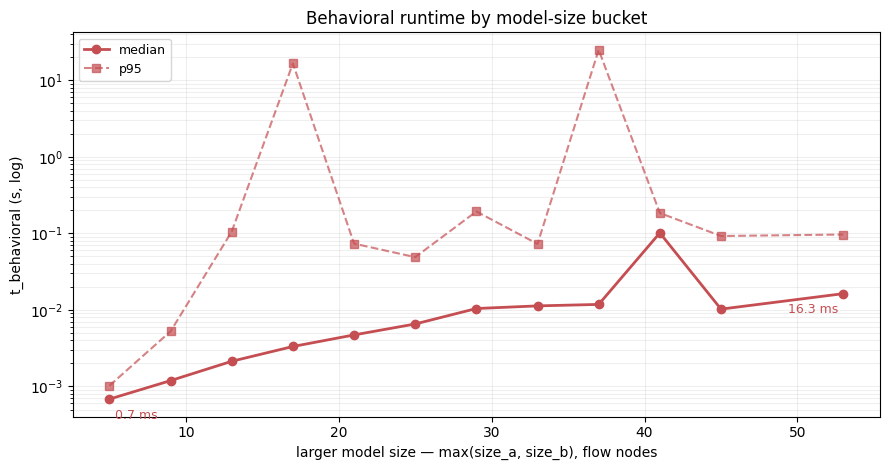

Per-bucket summary (buckets with n>=30):
    size_bin    n  median_ms   p95_ms
(2.999, 7.0]  528       0.68     1.02
 (7.0, 11.0] 1818       1.19     5.26
(11.0, 15.0] 1932       2.13   105.75
(15.0, 19.0] 1500       3.33 16653.29
(19.0, 23.0] 1125       4.72    73.52
(23.0, 27.0] 1482       6.55    48.96
(27.0, 31.0] 1068      10.44   193.39
(31.0, 35.0]  987      11.30    72.86
(35.0, 39.0]  885      11.81 25071.71
(39.0, 43.0]  151     101.52   184.72
(43.0, 47.0]  152      10.25    92.46
(51.0, 55.0]  153      16.33    96.74


In [6]:
ok['size_max'] = ok[['size_a', 'size_b']].max(axis=1)

# 4-node-wide buckets from the min to the max, keep only buckets with at least 30 pairs
edges = np.arange(int(ok['size_max'].min()), int(ok['size_max'].max()) + 5, 4)
ok['size_bin'] = pd.cut(ok['size_max'], bins=edges, include_lowest=True)
agg = (ok.groupby('size_bin', observed=True)['t_behavioral']
         .agg(median='median', p95=lambda v: v.quantile(0.95), n='size')
         .reset_index())
agg = agg[agg['n'] >= 30].copy()
agg['bin_mid'] = agg['size_bin'].apply(lambda iv: (iv.left + iv.right) / 2)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(agg['bin_mid'], agg['median'], marker='o', color='#c44e52', linewidth=2, label='median')
ax.plot(agg['bin_mid'], agg['p95'],    marker='s', color='#c44e52', linewidth=1.5,
        linestyle='--', alpha=0.7, label='p95')
ax.set_yscale('log')
ax.set_xlabel('larger model size — max(size_a, size_b), flow nodes')
ax.set_ylabel('t_behavioral (s, log)')
ax.set_title('Behavioral runtime by model-size bucket')
ax.grid(True, which='both', alpha=0.2)
ax.legend(loc='upper left', fontsize=9)

first, last = agg.iloc[0], agg.iloc[-1]
ax.annotate(f'{first["median"]*1000:.1f} ms',
            xy=(first['bin_mid'], first['median']),
            xytext=(4, -14), textcoords='offset points', fontsize=9, color='#c44e52')
ax.annotate(f'{last["median"]*1000:.1f} ms',
            xy=(last['bin_mid'], last['median']),
            xytext=(-4, -14), textcoords='offset points', ha='right', fontsize=9, color='#c44e52')

plt.tight_layout(); plt.show()

print('Per-bucket summary (buckets with n>=30):')
disp = agg.copy()
disp['median_ms'] = disp['median'] * 1000
disp['p95_ms']    = disp['p95'] * 1000
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(disp[['size_bin', 'n', 'median_ms', 'p95_ms']].to_string(index=False))

## 6. Per-model behavioral runtime

Aggregating `t_behavioral` per model reveals whether the tail is model-specific. Top-10 by mean runtime printed under the scatter.

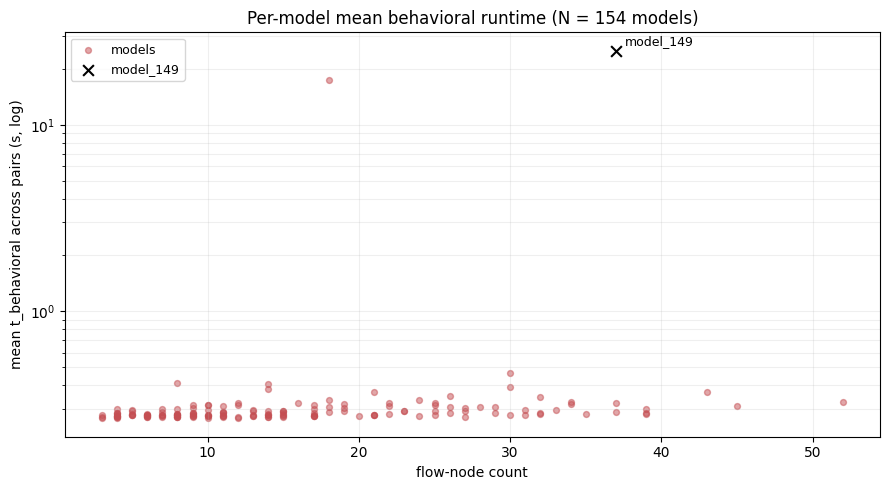

Top 10 models by mean t_behavioral:
    model  size  mean_t_behavioral  n_pairs
model_149    37            24.9323      153
model_100    18            17.4709      153
 model_70    30             0.4649      153
 model_65     8             0.4145      153
 model_71    14             0.4074      153
model_147    30             0.3911      153
 model_72    14             0.3843      153
 model_33    43             0.3701      153
model_126    21             0.3680      153
model_125    26             0.3496      153


In [7]:
# Melt the pair table to one row per (pair, side), then aggregate per model.
per_model = (
    pd.concat([
        ok[['model_a', 'size_a', 't_behavioral']].rename(columns={'model_a': 'model', 'size_a': 'size'}),
        ok[['model_b', 'size_b', 't_behavioral']].rename(columns={'model_b': 'model', 'size_b': 'size'}),
    ])
    .groupby('model')
    .agg(size=('size', 'first'),
         mean_t_behavioral=('t_behavioral', 'mean'),
         n_pairs=('t_behavioral', 'size'))
    .reset_index()
    .sort_values('mean_t_behavioral', ascending=False)
)

OUTLIER = per_model.iloc[0]['model']  # auto-select the slowest model
is_outlier = per_model['model'] == OUTLIER

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(per_model.loc[~is_outlier, 'size'], per_model.loc[~is_outlier, 'mean_t_behavioral'],
           s=18, alpha=0.5, color='#c44e52', label='models')
ax.scatter(per_model.loc[is_outlier, 'size'], per_model.loc[is_outlier, 'mean_t_behavioral'],
           s=60, color='black', marker='x', label=OUTLIER)
for _, row in per_model[is_outlier].iterrows():
    ax.annotate(row['model'], (row['size'], row['mean_t_behavioral']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)
ax.set_yscale('log')
ax.set_xlabel('flow-node count')
ax.set_ylabel('mean t_behavioral across pairs (s, log)')
ax.set_title(f'Per-model mean behavioral runtime (N = {len(per_model)} models)')
ax.grid(True, which='both', alpha=0.2)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

print('Top 10 models by mean t_behavioral:')
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(per_model.head(10).to_string(index=False))

## 7. Top-20 slowest pairs

In [8]:
TOP_N = 20
show_cols = [
    'pair_id', 'model_a', 'model_b', 'size_a', 'size_b',
    't_semantic', 't_structural', 't_behavioral', 't_total',
    'behavioral_timed_out_a', 'behavioral_timed_out_b',
]

print(f'=== Top {TOP_N} slowest pairs ===')
slow = ok.nlargest(TOP_N, 't_total')[show_cols].copy()
with pd.option_context('display.max_colwidth', 40, 'display.width', 200, 'display.float_format', '{:.4f}'.format):
    print(slow.to_string(index=False))

=== Top 20 slowest pairs ===
pair_id   model_a   model_b  size_a  size_b  t_semantic  t_structural  t_behavioral  t_total  behavioral_timed_out_a  behavioral_timed_out_b
 99_148 model_100 model_149      18      37      0.0867        0.0003       42.0672  42.1542                   False                   False
 17_148  model_18 model_149      37      37      0.1963        0.0003       30.5598  30.7565                   False                    True
 30_148  model_31 model_149      25      37      0.0929        0.0004       30.5352  30.6285                   False                    True
 19_148  model_20 model_149      22      37      0.0834        0.0003       30.4611  30.5448                   False                    True
 29_148  model_30 model_149      24      37      0.0737        0.0003       30.3354  30.4093                   False                    True
 84_148  model_85 model_149      34      37      0.1593        0.0003       30.1900  30.3496                   False         